# Homework 5: Exploration of Heart Disease Data (Use UCI Dataset)
## Part 1: Confidence Intervals for a Personalized Subgroup
    1. Define a subgroup of patients based on age, sex, chest pain type, or another variable of your choice.
    2. For this subgroup:
        - Randomly select three different sample sizes (e.g., small, medium, large).
        - Calculate the proportion of patients with heart disease.
        - Construct 95% confidence intervals.
    3. Questions:
        - How does interval width change with sample size?
        - Compare your subgroup’s proportion to the overall population.
        - Write 2–3 sentences explaining why your subgroup may differ from the population.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.proportion import proportion_confint, proportions_ztest, proportion_effectsize
from scipy import stats
from statsmodels.stats.power import NormalIndPower, TTestIndPower, TTestPower

In [39]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df = pd.read_csv(url, header=None)

df.columns = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang',
              'oldpeak','slope','ca','thal','target']

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [40]:
df.replace('?', np.nan, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')
df.dropna(inplace=True)

In [41]:
df.to_csv('Heartdisease.csv', index = False)

In [42]:
# Subgroup: Females (sex=0)
subgroup_df = df[df['sex'] == 0].copy()

subgroup_df['heart_disease'] = [1 if target > 0 else 0 for target in subgroup_df['target']]

subgroup_limit = len(subgroup_df)
print(f"Total patients in subgroup: {subgroup_limit}")

Total patients in subgroup: 96


In [43]:
def sample_ci(df, n, alpha=0.05):
    sample = df.sample(n, random_state=23)
    x = sample['heart_disease'].sum()
    p_hat = x / n
    ci_low, ci_upp = proportion_confint(count=x, nobs=n, alpha=alpha, method='wilson')
    return p_hat, ci_low, ci_upp

sample_sizes = [20, 50, 90]
ci_results = []

for n in sample_sizes:
    p_hat, low, up = sample_ci(subgroup_df, n)
    ci_results.append({'n': n,'p_hat': p_hat,'CI_low': low,'CI_high': up,'width': up - low})

ci_df = pd.DataFrame(ci_results)
ci_df

,n,p_hat,CI_low,CI_high,width
0,20,0.200000,0.080658,0.416017,0.335360
1,50,0.260000,0.158715,0.395532,0.236816
2,90,0.266667,0.186238,0.366198,0.179960


#### Questions:
- How does interval width change with sample size?

The interval width decreases as the sample size increases. The larger sample size provides a more precise estimate of the true proportion, resulting in a narrower confidence interval.

- Compare your subgroup’s proportion to the overall population.

The proportion of heart disease in the female subgroup (approximately 26.7% in the largest sample) is lower than the overall population average. While the population mean is influenced by both genders, the female data frequently shows a lower prevalence of heart disease compared to the male data.


- Write 2–3 sentences explaining why your subgroup may differ from the population.

The female subgroup may differ from the general population due to protective biological factors, such as higher estrogen and progesterone levels, which can reduce cardiovascular risk and males lack that protection. Other factors can include underreporting and underrepresentation of women in medical studies. 


## Part 2: Hypothesis Tests 

### Choose two tests that were not done in class. For each:

    - State your research question and define your null and alternative hypotheses.
    - Select an appropriate test (two-proportion, one-sample t-test, two-sample t-test).
    - Compute the test and report the statistic and p-value.
    - Visualize the data appropriately (bar chart, histogram, or boxplot).
    - Write 2–3 sentences interpreting your results.

#### Hypothesis Test I: T-Test One-sample
Is the average resting blood pressure level (trestbps) greater than from 130 mm/Hg?

In [44]:
# Null hypothesis
mu0 = 130

t_stat, p_value = stats.ttest_1samp(df['trestbps'], mu0, alternative='greater')

print(f"One-Sample t-Test Results:")
print(f"t-statistic = {t_stat:.3f}")
print(f"p-value = {p_value:.4f}")
print(f"Sample Mean = {df['trestbps'].mean():.2f}")

if p_value < 0.05:
    print(f"Reject H0: The average resting blood pressure level is {df['trestbps'].mean():.2f} and it is significantly greater than {mu0} mm/Hg.")
else:
    print(f"Fail to reject H0: The average cholesterol is {df['trestbps'].mean():.2f} and is not significantly greater than {mu0} mm/Hg.")


One-Sample t-Test Results:
t-statistic = 1.643
p-value = 0.0507
Sample Mean = 131.69
Fail to reject H0: The average cholesterol is 131.69 and is not significantly greater than 130 mm/Hg.


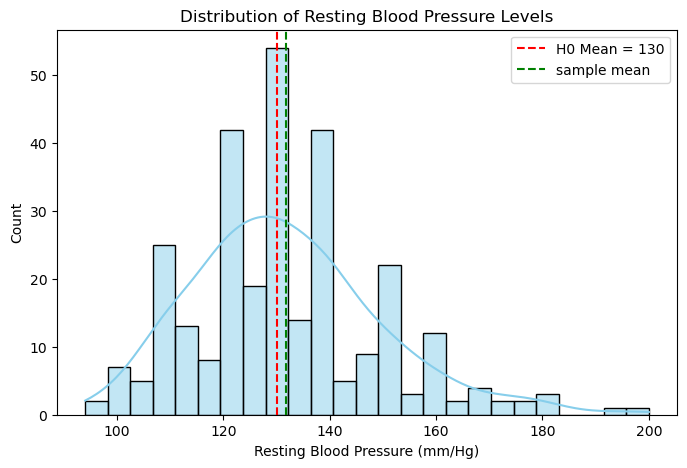

In [45]:
plt.figure(figsize=(8,5))
sns.histplot(df['trestbps'], bins=25, kde=True, color='skyblue')
plt.axvline(mu0, color='red', linestyle='--', label=f'H0 Mean = {mu0}')
plt.axvline(df['trestbps'].mean(), color='green', linestyle='--', label='sample mean')
plt.title('Distribution of Resting Blood Pressure Levels')
plt.xlabel('Resting Blood Pressure (mm/Hg)')
plt.ylabel('Count')
plt.legend()
plt.show()

Since the p-value (0.0507) is slightly above the standard significance level of 0.05, there is not have enough evidence to conclude that the average resting blood pressure is greater than 130 mm/Hg. Although the sample mean of 131.69 is higher than the null hypothesis, the difference is likely due to random sampling variability.

#### Hypothesis Test II: Two Proportion Test (Fasting blood sugar > or < 120 mg/dl)
Is the proportion of patients with high fasting blood sugar (over 120 mg/dl) significantly higher in patients with heart disease compared to those without?

In [46]:
with_disease = df[df['target'] > 0]['fbs']
no_disease = df[df['target'] == 0]['fbs']

count = np.array([with_disease.sum(), no_disease.sum()])
nobs = np.array([len(with_disease), len(no_disease)])

stat, pval = proportions_ztest(count, nobs, alternative='larger')

print(f"Z-statistic: {stat:.3f}, p-value: {pval:.4f}")

if pval < 0.05:
    print("Reject H0: The proportion of high fasting blood sugar is significantly higher in heart disease patients.")
else:
    print("Fail to reject H0: There is no significant difference in high fasting blood sugar and heart disease patients.")

print(f"Successes (High FBS): {count}")
print(f"Total n per group: {nobs}")

Z-statistic: 0.055, p-value: 0.4782
Fail to reject H0: There is no significant difference in high fasting blood sugar and heart disease patients.
Successes (High FBS): [20. 23.]
Total n per group: [137 160]


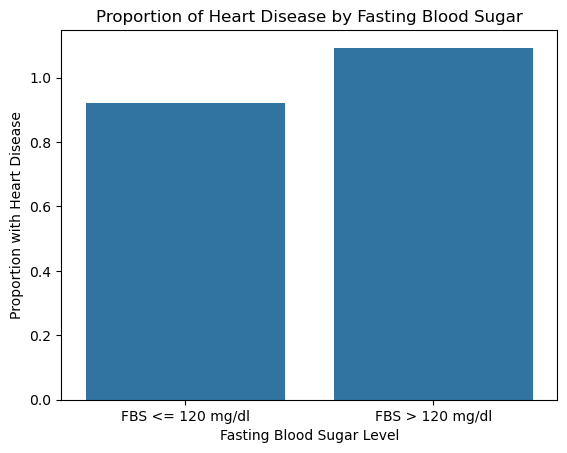

In [49]:
sns.barplot(x='fbs', y='target', data=df, errorbar=None)
plt.xticks([0, 1], ['FBS <= 120 mg/dl', 'FBS > 120 mg/dl'])
plt.xlabel('Fasting Blood Sugar Level')
plt.ylabel('Proportion with Heart Disease')
plt.title('Proportion of Heart Disease by Fasting Blood Sugar')

plt.show()

## Part 3: Type I and Type II Errors
Hypothesis Test I: T-Test One-sample

- What a Type I error would mean in your context.

A Type I error occurs if you reject the null hypothesis when it is actually true. In this context, it would be concluded that the average resting blood pressure is significantly greater than 130 mm/Hg, but in reality, it is around 130 mm/Hg or lower. This can lead to the belief that there is a trend of high blood pressure in this group that doesn't actually exist.

- What a Type II error would mean.

A Type II error occurs if you fail to reject the null hypothesis when it is actually false. In this context, it is concluded that there is no significant evidence that the blood pressure is over 130 mm/Hg, but in reality, the population average is significantly higher than 130 mm/Hg. This would cause a missed detection with overlooking a genuine health concern within the population.

- Explain which error would be more critical for patient care or medical research.

I think a Type II error would be morecritical for patient care and medical research. This is because in a Type II error it is concluding that a group of patients is "fine" (blood pressure is normal) when they are actually at risk. This leads to under-treatment, where patients who may need medication or lifestyle interventions do not receive them, potentially leading to heart attacks or strokes.


## Part 4: Sample Size and Power Planning
    - Pick one of your tests.
    - Assume α = 0.05 and desired power between 0.8–0.9.
    - Estimate effect size from your data or justify a hypothetical one.
    - Compute the required sample size.
    - Optional: Generate a power curve showing power vs sample size for your chosen effect size.
    - Write 2–3 sentences interpreting how sample size, effect size, and power interact.

#### Using Hypothesis Test II: Two Proportion Test (Fasting blood sugar > or < 120 mg/dl)

In [55]:
fbs_disease = df[df['target'] > 0]['fbs']
fbs_no_disease = df[df['target'] == 0]['fbs']

p1 = fbs_disease.mean()
p2 = fbs_no_disease.mean()

effect_size = proportion_effectsize(p1, p2)

alpha = 0.05
power = 0.80
analysis = NormalIndPower()
required_n = analysis.solve_power(effect_size=abs(effect_size), alpha=alpha, power=power, alternative='larger')

print(f"Proportion with high FBS (Disease): {p1:.3f}")
print(f"Proportion with high FBS (No Disease): {p2:.3f}")
print(f"Effect Size (Cohen's h) = {effect_size:.3f}")
print(f"Required sample size per group = {np.ceil(required_n)}")

Proportion with high FBS (Disease): 0.146
Proportion with high FBS (No Disease): 0.144
Effect Size (Cohen's h) = 0.006
Required sample size per group = 306540.0


The results show that the difference in high fasting blood sugar between these two groups is almost nonexistent (h = 0.006). Because this effect size is so small, a massive sample size of over 300,000 people per group is needed to reach a power of 0.8, as the test needs an enormous amount of data to distinguish such a small variation from unpredictable fluctuations.